## Testing `qaoa_pipeline`

We want to test `qaoa_pipline` using a known hamiltonian

Here we will use the max cut problem with $n=5$

From https://quantum.cloud.ibm.com/docs/en/tutorials/quantum-approximate-optimization-algorithm, we expect the following results

<img src='temp/maxcut1.png' alt='Graph' width='300'>
<img src='temp/maxcut2.png' alt='Distribution' width='500'>

The max cut hamiltonian reads $H_C = \frac{1}{2} \sum_{(i,j)\in E} ( \sigma^z_i \sigma^z_j - \textbf{1} ) \implies $ minimize



True


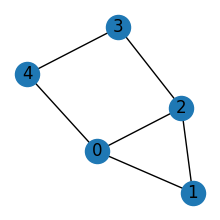

In [1]:
from qaoa_pipeline import *
import networkx as nx
import matplotlib.pyplot as plt
import pennylane as qml

graph = nx.Graph([(0, 1), (0,2), (0,4), (1,2), (2,3), (3,4)])
cost_h, mixer_h = qml.qaoa.maxcut(graph) # uses x_mixer ✓
costs = np.diagonal(qml.matrix(cost_h)) #
print(len(costs) == 2**5)
plt.figure(figsize=(2, 2))  
nx.draw(graph, with_labels=True)
plt.show()

In [2]:
# Since we now have the costs, we can build a qaoa circuit 
n=5
p=25
qaoa = QAOA_circuit(n=n, p=p//2, costs=costs) # initial depth p0
#Initialize parameters
gammas = np.linspace(0, 1, p//2)
betas = np.linspace(1, 0, p//2)
params = (gammas, betas)
energy = qaoa.cost_function(params)
print('Energy of unoptimized system', energy)
# Now we want to optimize the parameters to recover the Qiskit result
C = p//4
cheby_optimizer = ChebyshevOptimizer(qaoa, C)
II = IterativeInterpolation(params, qaoa, cheby_optimizer, p0=p//2, p_max=p, C=C, epsilon=1, tau=5, delta_p=5)
gammas, betas, energies, ARs = II.run()
print('Energy after optimization', list(energies.values())[-1])
print('It took', len(list(energies.keys())), 'iterations')
print('True energy minimum', np.real_if_close(qaoa.min_cost))
print('Achieved Approximation Ratio', np.real_if_close(list(ARs.values())[-1]))

Energy of unoptimized system -0.1630458782304951
Energy after optimization -4.933927181441367
It took 1 iterations
True energy minimum -5.0
Achieved Approximation Ratio 0.9867854362882735


#### Optimizer Analysis

**Remarks**: 
1. As one can see in the following, the results of the II algorithm are highly dependent on the choice of optimizer for the optimization of the Chebyshev coefficients. Here we used gradient based algorithms, the uathors of the JPMorgan paper, however, used gradient-free optimization (BOBYQA). The choice of the optimizer is cost hamiltonian specific and one might come back to this problem, when working on the UC cost Hamiltonian

<>:81: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:81: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
/var/folders/k8/5xy7bhr17fzf7mjz020r261r0000gn/T/ipykernel_76037/1215205754.py:81: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  ax[i].set_xlabel(r'$p_0 + \Delta p$')


GradientDescentOptimizer, C=2
GradientDescentOptimizer, C=5
GradientDescentOptimizer, C=10
AdamOptimizer, C=2
AdamOptimizer, C=5
AdamOptimizer, C=10
NesterovMomentumOptimizer, C=2
NesterovMomentumOptimizer, C=5
NesterovMomentumOptimizer, C=10


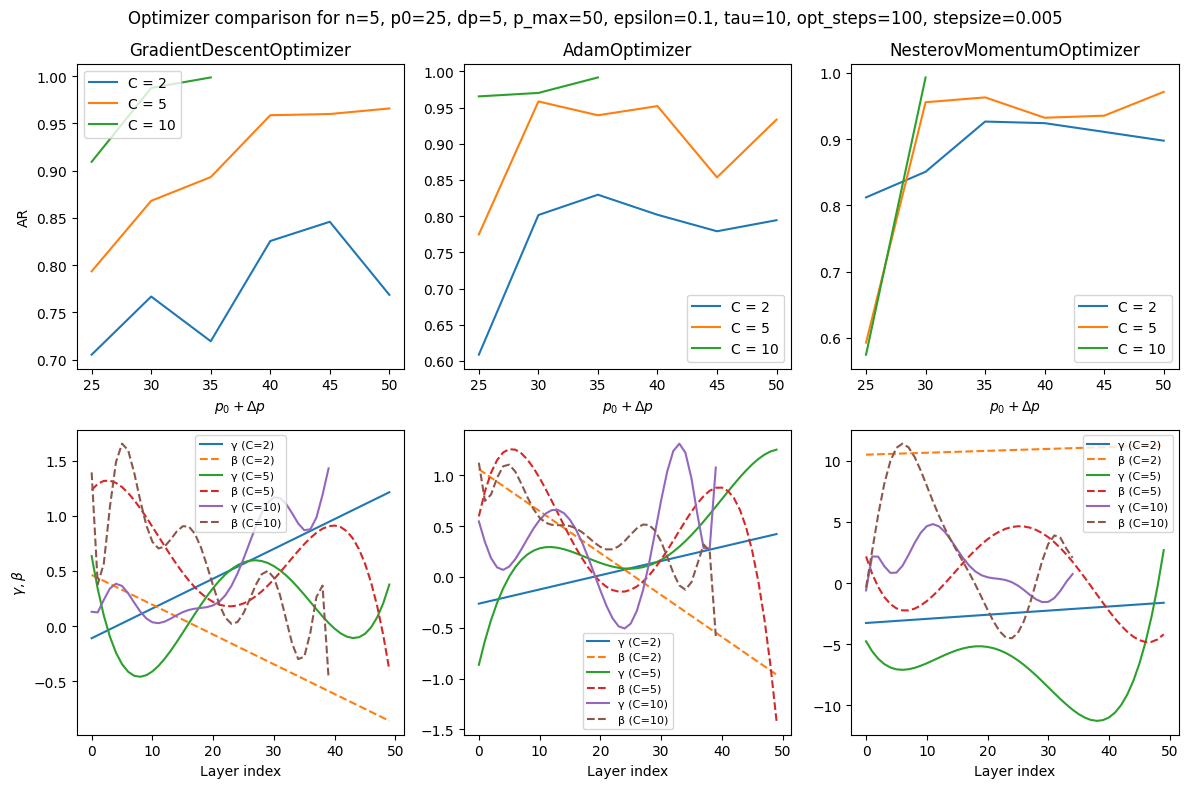

"\nfig, ax = plt.subplots(ncols=3, sharey=True, figsize=(12, 4))\nfig.suptitle(\n    f'Optimizer comparison for n={n}, p0={p0}, dp=5, p_max={p}, '\n    f'epsilon=0.1, tau=10, opt_steps=100, stepsize={stepsize}'\n)\n\n\nfor i, opt_cls in enumerate(optimizer_classes):\n    ax[i].set_title(opt_cls.__name__)\n    ax[i].set_xlabel(r'$p_0 + \\Delta p$')\n    if i == 0:\n        ax[i].set_ylabel('AR')\n\n    for C in C_vals:\n        print(f'{opt_cls.__name__}, C={C}')\n        qaoa = QAOA_circuit(n=n, p=p0, costs=costs)\n        cheby_optimizer = ChebyshevOptimizer(qaoa, C, stepsize=stepsize)\n        cheby_optimizer.optimizer = opt_cls(stepsize)   # fresh instance\n\n        II = IterativeInterpolation(\n            params, qaoa, cheby_optimizer,\n            p0=p0, p_max=p, C=C,\n            epsilon=0.1, tau=10,\n            delta_p=5, target_AR=.99,\n            opt_steps=100\n        )\n\n        gammas, betas, _, ARs = II.run()\n        xs = list(ARs.keys())\n        ys = np.real_if_clo

In [5]:
# 1. Compare different gradient-based optimizers
n=5
p=50
p0 = p // 2
stepsize=0.005


optimizer_classes = [
    qml.GradientDescentOptimizer,
    qml.AdamOptimizer,
    qml.NesterovMomentumOptimizer
]

C_vals = [2, 5, 10]
gammas = np.linspace(0, 1, p0)
betas = np.linspace(1, 0, p0)
params = (gammas, betas)

fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(12, 8))

fig.suptitle(
    f'Optimizer comparison for n={n}, p0={p0}, dp=5, p_max={p}, '
    f'epsilon=0.1, tau=10, opt_steps=100, stepsize={stepsize}'
)

for i, opt_cls in enumerate(optimizer_classes):
    # Titles
    ax[0, i].set_title(opt_cls.__name__)

    # Axis labels
    ax[0, i].set_xlabel(r'$p_0 + \Delta p$')
    ax[1, i].set_xlabel('Layer index')

    if i == 0:
        ax[0, i].set_ylabel('AR')
        ax[1, i].set_ylabel(r'$\gamma, \beta$')

    for C in C_vals:
        print(f'{opt_cls.__name__}, C={C}')
        
        qaoa = QAOA_circuit(n=n, p=p0, costs=costs)
        cheby_optimizer = ChebyshevOptimizer(qaoa, C, stepsize=stepsize)
        cheby_optimizer.optimizer = opt_cls(stepsize)

        II = IterativeInterpolation(
            params, qaoa, cheby_optimizer,
            p0=p0, p_max=p, C=C,
            epsilon=0.1, tau=10,
            delta_p=5, target_AR=.99,
            opt_steps=100
        )

        gammas, betas, _, ARs = II.run()

        # ---- Top row: AR ----
        xs = list(ARs.keys())
        ys = np.real_if_close(np.array(list(ARs.values())))
        ax[0, i].plot(xs, ys, label=f'C = {C}')

        # ---- Bottom row: parameters ----
        layers = np.arange(len(gammas))
        ax[1, i].plot(layers, gammas, linestyle='-', label=f'γ (C={C})')
        ax[1, i].plot(layers, betas, linestyle='--', label=f'β (C={C})')

    ax[0, i].legend()
    ax[1, i].legend(fontsize=8)

plt.tight_layout()
plt.show()

"""
fig, ax = plt.subplots(ncols=3, sharey=True, figsize=(12, 4))
fig.suptitle(
    f'Optimizer comparison for n={n}, p0={p0}, dp=5, p_max={p}, '
    f'epsilon=0.1, tau=10, opt_steps=100, stepsize={stepsize}'
)


for i, opt_cls in enumerate(optimizer_classes):
    ax[i].set_title(opt_cls.__name__)
    ax[i].set_xlabel(r'$p_0 + \Delta p$')
    if i == 0:
        ax[i].set_ylabel('AR')

    for C in C_vals:
        print(f'{opt_cls.__name__}, C={C}')
        qaoa = QAOA_circuit(n=n, p=p0, costs=costs)
        cheby_optimizer = ChebyshevOptimizer(qaoa, C, stepsize=stepsize)
        cheby_optimizer.optimizer = opt_cls(stepsize)   # fresh instance

        II = IterativeInterpolation(
            params, qaoa, cheby_optimizer,
            p0=p0, p_max=p, C=C,
            epsilon=0.1, tau=10,
            delta_p=5, target_AR=.99,
            opt_steps=100
        )

        gammas, betas, _, ARs = II.run()
        xs = list(ARs.keys())
        ys = np.real_if_close(np.array(list(ARs.values())))
        ax[i].plot(xs, ys, label=f'C = {C}')

    ax[i].legend()

plt.tight_layout()
plt.show()
"""


**stepsize=0.1**
Optimizing C=2
dict_keys([25, 30, 35, 40, 45, 50]) [0.4469746  0.55873149 0.44577402 0.59615921 0.62533219 0.52994459]
Optimizing C=5
dict_keys([25, 30, 35, 40, 45, 50]) [0.67468801 0.65138171 0.66404231 0.49031088 0.65156143 0.49773739]
Optimizing C=10
dict_keys([25, 30, 35, 40, 45, 50]) [0.47661216 0.48325035 0.43821474 0.71385206 0.35129656 0.6129177 ]

**stepsize=0.01**

Optimizing C=2
dict_keys([25, 30, 35, 40, 45, 50]) [0.63162355 0.71766963 0.56295196 0.60959267 0.48578833 0.67295785]
Optimizing C=5
dict_keys([25, 30, 35, 40, 45, 50]) [0.72087462 0.71821786 0.71901576 0.71352854 0.36125683 0.67450947]
Optimizing C=10
dict_keys([25, 30, 35, 40, 45, 50]) [0.78615725 0.51867296 0.58721351 0.52939944 0.4791838  0.59292186]

**stepsize=0.001**

Optimizing C=2
dict_keys([25, 30, 35, 40, 45, 50]) [0.22940917 0.566655   0.71929908 0.85313756 0.68070605 0.71380358]
Optimizing C=5
dict_keys([25, 30, 35, 40, 45, 50]) [0.69417397 0.75099098 0.77386008 0.76068305 0.7558342  0.75625889]
Optimizing C=10
dict_keys([25, 30, 35, 40, 45, 50]) [0.89637469 0.87575482 0.85988802 0.8395053  0.81741055 0.83954053]

**stepsize=0.005**

Optimizing C=2
dict_keys([25, 30, 35, 40, 45, 50]) [0.7051887  0.7461803  0.75035924 0.76114648 0.76389281 0.76926621]
Optimizing C=5
dict_keys([25, 30, 35, 40]) [0.79346345 0.79667135 0.81365169 0.98908047]
Optimizing C=10
dict_keys([25, 30, 35, 40, 45, 50]) [0.90943504 0.83484832 0.86444536 0.874608   0.79977474 0.9449303 ]

### Max Cut Probability Distribution

In [ ]:
### Plot Max Cut Probability distribution
# Same example as above
n=5
p=25
qaoa = QAOA_circuit(n=n, p=p//2, costs=costs) # initial depth p0
#Initialize parameters
gammas = np.linspace(0, 1, p//2)
betas = np.linspace(1, 0, p//2)
params = (gammas, betas)
energy = qaoa.cost_function(params)
print('Energy of unoptimized system', energy)
# Now we want to optimize the parameters to recover the Qiskit result
C = p//4
cheby_optimizer = ChebyshevOptimizer(qaoa, C)
II = IterativeInterpolation(params, qaoa, cheby_optimizer, p0=p//2, p_max=p, C=C, epsilon=1, tau=5, delta_p=5)
gammas, betas, energies, ARs = II.run()
print('Energy after optimization', list(energies.values())[-1])
print('It took', len(list(energies.keys())), 'iterations')
print('True energy minimum', np.real_if_close(qaoa.min_cost))
print('Achieved Approximation Ratio', np.real_if_close(list(ARs.values())[-1]))

#QAOA with tuned parameters
params = (gammas, betas)
qaoa_tuned = QAOA_circuit(n, len(gammas), costs).distribution(params)

Energy of unoptimized system -0.1630458782304951
Energy after optimization -4.933927181441367
It took 1 iterations
True energy minimum -5.0
Achieved Approximation Ratio 0.9867854362882735


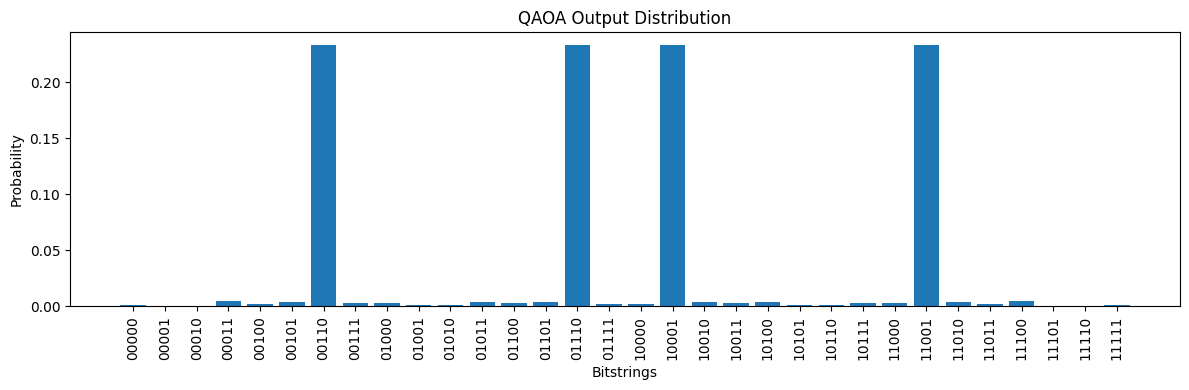

In [10]:
probs = qaoa_tuned  # output of distribution()

bitstrings = [format(i, f"0{n}b") for i in range(2**n)]

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.bar(bitstrings, probs)

plt.xlabel("Bitstrings")
plt.ylabel("Probability")
plt.title("QAOA Output Distribution")

plt.xticks(rotation=90)  # rotate labels for readability
plt.tight_layout()
plt.show()

**Our solution is therefore 4-fold degenerate (same as in the qiskit tutorial) but with different labelling. Plugging the results into the cost function should yield its algebraic minimum -5**

In [12]:
x_vals = [int('00110', 2), int('01110', 2), int('10001', 2), int('11001', 2)]
print([costs[x] for x in x_vals])

[np.complex128(-5+0j), np.complex128(-5+0j), np.complex128(-5+0j), np.complex128(-5+0j)]


**We there fore conclude that `qaoa_pipeline.py` yields right results and it is only the optimization that can potentially be improved. ${}^\square$**

# -----------------------

### Important

1. Small resistances $B_{kl} = \frac{X_{kl}}{R^2_{kl}+X_{kl}^2} \approx X_{kl}^{-1}$ is not a good approximation. So we include resistances $\implies$ we have to be careful with ieee57 because this data set does NOT fulfill $X_{kl} \gg R_{kl}$ and it is a basic assumption for the **DC Pwerflow approxmiation**
2. Off-Diagonal Elements $B[i,j] = - b_{ij}$, Diagonal $B[i,i] = \sum_j B_{}ij$
3. DC Power Approximation $P_{kl} = \frac{\theta_k - \theta_l}{X_{kl}} \implies B \theta = P$ might not be a good approximatin for ieee57, implement `PowerGrid.random()` grid with  $X_{kl} \gg R_{kl}$ 


### IEEE57 Data Set

In [ ]:
# Auxilary 

from powergrid import *
import networkx as nx
import matplotlib.pyplot as plt


#Plot Power Grid Graph

def plot_grid(pg: PowerGrid):     
    G = nx.from_scipy_sparse_array(pg.graph)
    pos = nx.spring_layout(G)  # layout of the nodes
    # Draw nodes
    nx.draw_networkx_nodes(G, pos, node_color='skyblue', node_size=500)
    # Draw edges
    nx.draw_networkx_edges(G, pos, width=2)
    # Draw labels
    nx.draw_networkx_labels(G, pos, font_size=12)
    plt.axis('off')
   # plt.show()

def plot_B(pg: Powergrid):   
    plt.imshow(pg.B.toarray())
    plt.title(r'$B_{kl}$ of ieee57')
    plt.xlabel('k')
    plt.ylabel('l')
    plt.colorbar()
    #plt.show()

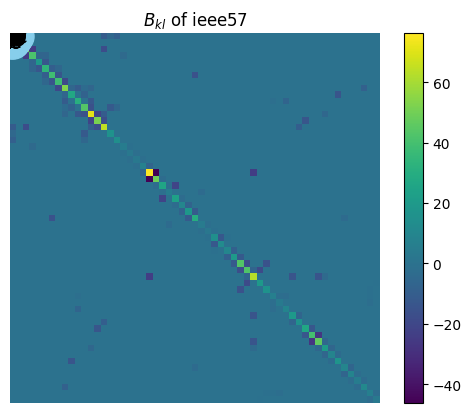

In [ ]:
# Visualizing the IEEE57 Data Set

#print(pg.B)
#print(type(pg.P))
#print(pg.B.shape)
#print(pg.P.shape)
#print(pg.P)

pg = PowerGrid.ieee57()
plot_grid(pg)
plot_B(pg)

### Random Power Grids

TypeError: PowerGrid.loss_function() missing 1 required positional argument: 'x'

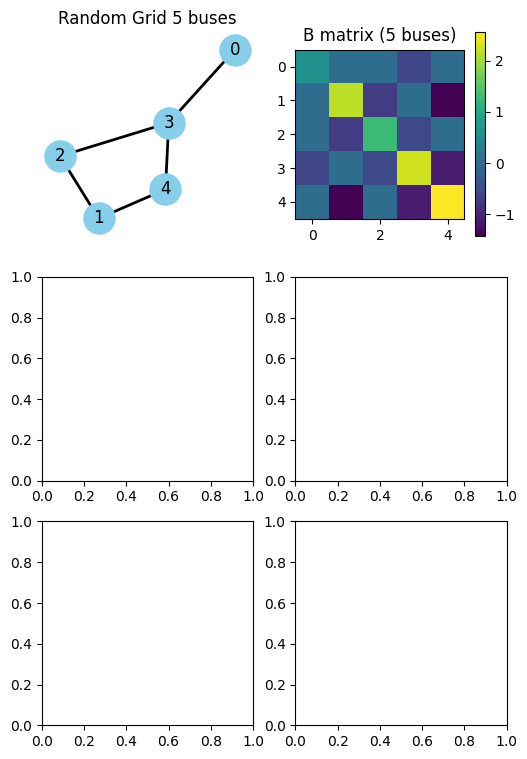

In [ ]:
import matplotlib.pyplot as plt

n_vals = [5, 10, 20]
RPGs = [PowerGrid.random(n) for n in n_vals]

# assume RPGs is your list of PowerGrid instances
n_grids = len(RPGs)
fig, axes = plt.subplots(n_grids, 2, figsize=(6, 3*n_grids))  # 2 columns: grid + B

for i, rpg in enumerate(RPGs):
    # Plot network topology
    plt.sca(axes[i, 0])
    plot_grid(rpg)  # make sure this plots on current axes
    plt.title(f'Random Grid {rpg.n} buses')

    # Plot B matrix
    plt.sca(axes[i, 1])
    plt.imshow(rpg.B.toarray(), cmap='viridis')
    plt.colorbar()
    plt.title(f'B matrix ({rpg.n} buses)')
    print('Cost function value', rpg.loss_function(c=[1]*n_vals[i])) # right now power vector is not part of cost function, so it simply yields n
plt.tight_layout()
plt.show()

In [ ]:
help(PowerGrid.random)

Help on method random in module powergrid:

random(n: int, max_ratio: float = 1.0, min_reactance: float = 0.1, seed=1234) -> PowerGrid class method of powergrid.PowerGrid
    Generate a random, connected power grid network for DC power flow experiments.

    The network is created by first building a spanning tree to ensure connectivity,
    then adding extra random edges. Branch reactances and resistances, as well as
    bus loads and generator capacities, are sampled from uniform distributions.

    Important notes
    ---------------
    - Reactances X are strictly positive (X > 0) and sampled uniformly in [min_reactance, 1].
    - Resistances R are small relative to X, sampled uniformly in [0, max_ratio].
    - Generator outputs and bus loads are sampled uniformly in [0, 1].
    - No negative reactances are allowed.
    - The graph is connected but not fully connected; sparsity is controlled by
    the number of extra edges added.

    Parameters
    ----------
    n : int
        